# Ethene grid generator

Use one source geometry as a reference to construct an ethene grid.

The grid spans C=C bond lengths from 1.1 to 3.0 Å in 0.1 Å steps and H-C-C-H dihedrals from 0.01 to 180.01° in 5° steps.

In [73]:
from pathlib import Path

import numpy as np
from ase import Atoms
from ase.io import write

SOURCE_XYZ = Path("../data/A01_ethene/static/A01_ethene_grid_static_CASSCF_FINAL.xyz")
OUTPUT_XYZ = Path("../data/A01_ethene/static/A01_ethene_grid_static_CASSCF_generated_bond_dihedral.xyz")
REFERENCE_CC_BOND_LENGTH = 1.336172  # Å; selects the source reference geometry.
REFERENCE_DIHEDRAL = 0.0  # degrees; selects the source reference geometry.
CC_BOND_LENGTHS = np.round(np.arange(1.1, 3.0 + 0.05, 0.1), 6)
DIHEDRAL_ANGLES = np.round(np.arange(0.01, 180.01 + 2.5, 5.0), 6)


def h_c_c_h_dihedral(positions):
    """Return the H(2)-C(0)-C(1)-H(3) dihedral in degrees."""
    a, b, c, d = positions[2], positions[0], positions[1], positions[3]
    bond0 = -(b - a)
    bond1 = c - b
    bond2 = d - c
    bond1 /= np.linalg.norm(bond1)
    v = bond0 - np.dot(bond0, bond1) * bond1
    w = bond2 - np.dot(bond2, bond1) * bond1
    return np.degrees(np.arctan2(np.dot(np.cross(bond1, v), w), np.dot(v, w)))


def read_raw_xyz_frames(path):
    """Read frames while retaining their original raw extended-XYZ text."""
    lines = path.read_text().splitlines(keepends=True)
    frames = []
    cursor = 0
    while cursor < len(lines):
        if not lines[cursor].strip():
            cursor += 1
            continue
        natoms = int(lines[cursor])
        stop = cursor + natoms + 2
        if stop > len(lines):
            raise ValueError(f"Incomplete frame starting at line {cursor + 1}")
        atom_lines = lines[cursor + 2 : stop]
        positions = np.array([[float(value) for value in line.split()[1:4]] for line in atom_lines])
        if positions.shape != (6, 3):
            raise ValueError(f"Expected six atoms, got {positions.shape[0]}")
        frames.append({"source_frame_index": len(frames), "raw": "".join(lines[cursor:stop]), "positions": positions})
        cursor = stop
    return frames


source_frames = read_raw_xyz_frames(SOURCE_XYZ)
for frame in source_frames:
    positions = frame["positions"]
    frame["bond"] = round(float(np.linalg.norm(positions[1] - positions[0])), 6)
    frame["dihedral"] = round(float(h_c_c_h_dihedral(positions)), 6)

reference_source_frame = min(
    source_frames,
    key=lambda frame: (frame["bond"] - REFERENCE_CC_BOND_LENGTH) ** 2
    + ((frame["dihedral"] - REFERENCE_DIHEDRAL + 180) % 360 - 180) ** 2,
)
if not np.isclose(reference_source_frame["bond"], REFERENCE_CC_BOND_LENGTH, atol=1e-6):
    raise ValueError("The requested C=C reference geometry is unavailable")
REFERENCE_POSITIONS = reference_source_frame["positions"].copy()
REFERENCE_SOURCE_FRAME_INDEX = reference_source_frame["source_frame_index"]

carbon_indices = (0, 1)
hydrogen_indices = (2, 3, 4, 5)
hydrogens_by_carbon = {
    carbon: tuple(
        hydrogen for hydrogen in hydrogen_indices
        if np.argmin([np.linalg.norm(REFERENCE_POSITIONS[hydrogen] - REFERENCE_POSITIONS[c]) for c in carbon_indices])
        == carbon
    )
    for carbon in carbon_indices
}
if 2 not in hydrogens_by_carbon[0] or 3 not in hydrogens_by_carbon[1]:
    raise ValueError("Unexpected ethene atom ordering in the reference geometry")

def wrapped_angle_difference(actual, target):
    """Return actual - target in the interval [-180, 180)."""
    return (actual - target + 180.0) % 360.0 - 180.0

def rotate_about_axis(positions, indices, origin, axis, angle_degrees):
    """Rotate selected positions using Rodrigues' rotation formula."""
    angle = np.radians(angle_degrees)
    vectors = positions[list(indices)] - origin
    positions[list(indices)] = (
        origin
        + vectors * np.cos(angle)
        + np.cross(axis, vectors) * np.sin(angle)
        + np.outer(np.dot(vectors, axis), axis) * (1.0 - np.cos(angle))
    )

reference_bond = float(np.linalg.norm(REFERENCE_POSITIONS[1] - REFERENCE_POSITIONS[0]))
reference_dihedral = float(h_c_c_h_dihedral(REFERENCE_POSITIONS))
cc_axis = (REFERENCE_POSITIONS[1] - REFERENCE_POSITIONS[0]) / reference_bond
moving_fragment = (1, *hydrogens_by_carbon[1])
trial_positions = REFERENCE_POSITIONS.copy()
rotate_about_axis(trial_positions, hydrogens_by_carbon[1], REFERENCE_POSITIONS[0], cc_axis, 1.0)
rotation_sign = np.sign(wrapped_angle_difference(h_c_c_h_dihedral(trial_positions), reference_dihedral))
if rotation_sign == 0:
    raise ValueError("Could not calibrate the dihedral rotation direction")

bond_coordinates = [float(value) for value in CC_BOND_LENGTHS]
dihedral_coordinates = [float(value) for value in DIHEDRAL_ANGLES]
selected_bonds = bond_coordinates
selected_dihedrals = dihedral_coordinates
selected_keys = [(bond, dihedral) for bond in selected_bonds for dihedral in selected_dihedrals]
frames = []
frame_by_coordinate = {}
generated_atoms = []

for source_frame_index, (bond, dihedral) in enumerate(selected_keys):
    positions = REFERENCE_POSITIONS.copy()
    positions[list(moving_fragment)] += (bond - reference_bond) * cc_axis
    rotation_angle = wrapped_angle_difference(dihedral, reference_dihedral) / rotation_sign
    rotate_about_axis(positions, hydrogens_by_carbon[1], positions[0], cc_axis, rotation_angle)

    measured_bond = float(np.linalg.norm(positions[1] - positions[0]))
    measured_dihedral = float(h_c_c_h_dihedral(positions))
    if not np.isclose(measured_bond, bond, atol=1e-8):
        raise AssertionError(f"C=C bond mismatch: expected {bond}, got {measured_bond}")
    if abs(wrapped_angle_difference(measured_dihedral, dihedral)) > 1e-8:
        raise AssertionError(f"Dihedral mismatch: expected {dihedral}, got {measured_dihedral}")

    frame = {
        "source_frame_index": source_frame_index,
        "reference_source_frame_index": REFERENCE_SOURCE_FRAME_INDEX,
        "positions": positions,
        "bond": bond,
        "dihedral": dihedral,
    }
    frames.append(frame)
    frame_by_coordinate[(bond, dihedral)] = frame
    atoms = Atoms(symbols=["C", "C", "H", "H", "H", "H"], positions=positions, pbc=False)
    atoms.info = {
        "source_frame_index": source_frame_index,
        "reference_source_frame_index": REFERENCE_SOURCE_FRAME_INDEX,
        "grid_cc_bond_angstrom": bond,
        "grid_dihedral_deg": dihedral,
    }
    generated_atoms.append(atoms)

expected_grid_size = len(CC_BOND_LENGTHS) * len(DIHEDRAL_ANGLES)
if len(selected_keys) != expected_grid_size or expected_grid_size != 20 * 37:
    raise AssertionError(f"Expected a 20 x 37 grid, got {len(selected_keys)} geometries")
write(OUTPUT_XYZ, generated_atoms, format="extxyz")
print(f"Wrote {len(generated_atoms)} generated geometries to {OUTPUT_XYZ.resolve()}")
print(f"Grid shape: {len(CC_BOND_LENGTHS)} bond coordinates x {len(DIHEDRAL_ANGLES)} dihedrals")


Wrote 740 generated geometries to /home/lim_yt/X-MACE-sampling/data/A01_ethene/static/A01_ethene_grid_static_CASSCF_generated_bond_dihedral.xyz
Grid shape: 20 bond coordinates x 37 dihedrals


# Normal modes

Find the normal modes of ethene.

In [53]:
from ase import Atoms
from xtb.ase.calculator import XTB
from wfl.configset import ConfigSet, OutputSpec
from wfl.generate import normal_modes as nm

REFERENCE_NM_XYZ = Path("ethene_reference_normal_modes.xyz")
reference_atoms = Atoms(
    symbols=["C", "C", "H", "H", "H", "H"],
    positions=REFERENCE_POSITIONS,
    pbc=False,
)
configset = ConfigSet([reference_atoms])
outputspec = OutputSpec(REFERENCE_NM_XYZ, overwrite=True)

calc = (XTB, [], {"method": "GFN2-xTB"})
prop_prefix = "xtb2_"

nm.generate_normal_modes_parallel_hessian(inputs=configset,
                                          outputs=outputspec,
                                          calculator=calc,
                                          prop_prefix=prop_prefix)

print(
    f"Wrote normal modes for C-C = {reference_bond:.6f} Å, "
    f"dihedral = {reference_dihedral:.1f}° to {REFERENCE_NM_XYZ.resolve()}"
)

Wrote normal modes for C-C = 1.336172 Å, dihedral = 0.0° to /home/lim_yt/X-MACE-sampling/notebooks/ethene_reference_normal_modes.xyz


In [54]:
from ase.io import read
from wfl.generate import normal_modes as nm

at = read(REFERENCE_NM_XYZ)
ethene_nm = nm.NormalModes(at, "xtb2_")

# Writes trajectories of the selected normal modes to file.
ethene_nm.view()

# prints frequencies
ethene_nm.summary()

---------------------

  #    meV     cm^-1

---------------------

  0   18.9 i   152.1 i
  1    0.0 i     0.0 i
  2    0.0 i     0.0 i
  3   48.1     387.7  
  4   56.0     451.8  
  5   60.2     485.5  
  6  100.5     810.4  
  7  107.0     863.2  
  8  117.7     949.4  
  9  125.7    1013.6  
 10  131.6    1061.2  
 11  170.6    1375.9  
 12  175.4    1414.4  
 13  201.8    1627.4  
 14  376.7    3038.2  
 15  377.0    3040.5  
 16  381.7    3078.9  
 17  382.6    3086.2  
---------------------



# Range calculator

Input the desired ranges for CH bond length,  CCH bond angle, HCH bond angle, pyramidalisation.
For the corresponding vibration modes, calculators will return the q ranges needed to stay in the desired ranges.

In [74]:
# C-H displacement-range calculator.
CH_MODES = (14, 15, 16, 17)
CH_BOND_LENGTH_RANGE = (0.82, 2.00)  # Å

if not CH_MODES or len(set(CH_MODES)) != len(CH_MODES):
    raise ValueError("CH_MODES must contain unique mode indices")
CH_BOND_LENGTH_RANGE = tuple(float(value) for value in CH_BOND_LENGTH_RANGE)
if (len(CH_BOND_LENGTH_RANGE) != 2 or not np.all(np.isfinite(CH_BOND_LENGTH_RANGE))
        or CH_BOND_LENGTH_RANGE[0] <= 0 or CH_BOND_LENGTH_RANGE[0] >= CH_BOND_LENGTH_RANGE[1]):
    raise ValueError("CH_BOND_LENGTH_RANGE must be an ordered, positive (minimum, maximum) pair")

normal_mode_atoms = read(REFERENCE_NM_XYZ)
ethene_nm = nm.NormalModes(normal_mode_atoms, prop_prefix)
if min(CH_MODES) < 0 or max(CH_MODES) >= ethene_nm.num_nm:
    raise ValueError(f"C-H modes {CH_MODES} are unavailable")
mode_vectors = {mode: ethene_nm.modes[mode] for mode in CH_MODES}

symbols = np.asarray(normal_mode_atoms.get_chemical_symbols())
carbon_indices = np.flatnonzero(symbols == "C")
hydrogen_indices = np.flatnonzero(symbols == "H")
if len(carbon_indices) != 2 or len(hydrogen_indices) != 4:
    raise ValueError("Expected ethene to contain two carbons and four hydrogens")

# Associate each H with its closest C in the reference geometry.
CH_BONDS = tuple(
    (int(carbon_indices[np.argmin(np.linalg.norm(
        normal_mode_atoms.positions[hydrogen] - normal_mode_atoms.positions[carbon_indices],
        axis=1,
    ))]), int(hydrogen))
    for hydrogen in hydrogen_indices
)
if any(
    np.linalg.norm(normal_mode_atoms.positions[hydrogen] - normal_mode_atoms.positions[carbon]) >= 1.5
    for carbon, hydrogen in CH_BONDS
):
    raise ValueError("Could not identify four C-H bonds from the reference geometry")

for base_key in selected_keys:
    positions = frame_by_coordinate[base_key]["positions"]
    for carbon, hydrogen in CH_BONDS:
        distances_to_carbons = np.linalg.norm(
            positions[hydrogen] - positions[carbon_indices], axis=1
        )
        if (
            carbon != carbon_indices[np.argmin(distances_to_carbons)]
            or np.linalg.norm(positions[hydrogen] - positions[carbon]) >= 1.5
        ):
            raise ValueError(f"C-H bonding assignment changed at grid coordinate {base_key}")

def ch_boundary_roots(positions, mode_vector, bond, target_length):
    """Return all real q values where one C-H bond reaches target_length."""
    carbon, hydrogen = bond
    relative_position = positions[hydrogen] - positions[carbon]
    relative_mode = mode_vector[hydrogen] - mode_vector[carbon]
    a = np.dot(relative_mode, relative_mode)
    b = 2 * np.dot(relative_position, relative_mode)
    c = np.dot(relative_position, relative_position) - target_length**2
    if a <= np.finfo(float).eps:
        return ()
    discriminant = b**2 - 4 * a * c
    if discriminant < 0:
        return ()
    roots = np.sort(((-b - np.sqrt(discriminant)) / (2 * a),
                     (-b + np.sqrt(discriminant)) / (2 * a)))
    return roots

def nearest_q_exits(mode, coordinates, value_at_q, roots_at_boundary, value_range):
    """Find the nearest valid-range exit on each side of q=0 across the grid."""
    lower, upper = value_range
    negative_candidates, positive_candidates = [], []
    for base_key in selected_keys:
        positions = frame_by_coordinate[base_key]["positions"]
        for coordinate in coordinates:
            initial_value = value_at_q(positions, mode_vectors[mode], coordinate, 0.0)
            if not lower - 1e-8 <= initial_value <= upper + 1e-8:
                raise ValueError(
                    f"Mode {mode}: unperturbed {coordinate} value {initial_value:.6f} is outside "
                    f"the requested range {value_range} at {base_key}"
                )
            for boundary in value_range:
                for root in roots_at_boundary(positions, mode_vectors[mode], coordinate, boundary):
                    candidate = (float(root), base_key, coordinate, boundary)
                    if root < -1e-10:
                        negative_candidates.append(candidate)
                    elif root > 1e-10:
                        positive_candidates.append(candidate)
    if not negative_candidates or not positive_candidates:
        raise ValueError(f"Mode {mode} has no finite q range for {value_range}")
    return (
        max(negative_candidates, key=lambda item: item[0]),
        min(positive_candidates, key=lambda item: item[0]),
    )

def ch_distance(positions, mode_vector, bond, q):
    carbon, hydrogen = bond
    displaced = positions + q * mode_vector
    return float(np.linalg.norm(displaced[hydrogen] - displaced[carbon]))

CH_MODE_RANGES_BY_MODE = {}
for mode in CH_MODES:
    negative_exit, positive_exit = nearest_q_exits(
        mode, CH_BONDS, ch_distance, ch_boundary_roots, CH_BOND_LENGTH_RANGE
    )
    CH_MODE_RANGES_BY_MODE[mode] = (negative_exit[0], positive_exit[0])
    for exit_candidate in (negative_exit, positive_exit):
        q, base_key, bond, boundary = exit_candidate
        value = ch_distance(frame_by_coordinate[base_key]["positions"], mode_vectors[mode], bond, q)
        if not np.isclose(value, boundary, atol=1e-8):
            raise AssertionError("C-H target root did not reproduce the target length")
    print(
        f"C-H mode {mode}: q range {CH_MODE_RANGES_BY_MODE[mode]}; "
        f"negative: {negative_exit[2]} at {negative_exit[1]} reaches {negative_exit[3]} Å; "
        f"positive: {positive_exit[2]} at {positive_exit[1]} reaches {positive_exit[3]} Å"
    )



C-H mode 14: q range (-1.5518699586668623, 0.45245498437241227); negative: (0, 2) at (1.1, 0.01) reaches 2.0 Å; positive: (0, 2) at (1.1, 0.01) reaches 0.82 Å
C-H mode 15: q range (-0.4594993584330527, 0.4594993595357959); negative: (1, 3) at (1.1, 0.01) reaches 0.82 Å; positive: (0, 2) at (1.1, 0.01) reaches 0.82 Å
C-H mode 16: q range (-0.3733166095056574, 0.3733166095056574); negative: (0, 2) at (1.1, 0.01) reaches 0.82 Å; positive: (0, 5) at (1.1, 0.01) reaches 0.82 Å
C-H mode 17: q range (-0.37065449355284985, 0.37065449355284985); negative: (0, 2) at (1.1, 0.01) reaches 0.82 Å; positive: (0, 5) at (1.1, 0.01) reaches 0.82 Å


In [75]:
# C-C-H angle displacement-range calculator.
CCH_MODES = (7, 9)
CCH_ANGLE_RANGE = (17.3, 178.1)  # degrees

if not CCH_MODES or len(set(CCH_MODES)) != len(CCH_MODES):
    raise ValueError("CCH_MODES must contain unique mode indices")
if set(CH_MODES) & set(CCH_MODES):
    raise ValueError("CH_MODES and CCH_MODES must not overlap")
CCH_ANGLE_RANGE = tuple(float(value) for value in CCH_ANGLE_RANGE)
if (len(CCH_ANGLE_RANGE) != 2 or not np.all(np.isfinite(CCH_ANGLE_RANGE))
        or not 0 < CCH_ANGLE_RANGE[0] < CCH_ANGLE_RANGE[1] < 180):
    raise ValueError("CCH_ANGLE_RANGE must be an ordered pair strictly between 0 and 180 degrees")
if min(CCH_MODES) < 0 or max(CCH_MODES) >= ethene_nm.num_nm:
    raise ValueError(f"C-C-H modes {CCH_MODES} are unavailable")
mode_vectors.update({mode: ethene_nm.modes[mode] for mode in CCH_MODES})

CCH_ANGLES = tuple(
    (next(other for other in carbon_indices if other != carbon), carbon, hydrogen)
    for carbon, hydrogen in CH_BONDS
)

def cch_angle(positions, mode_vector, angle_atoms, q):
    outer_carbon, central_carbon, hydrogen = angle_atoms
    displaced = positions + q * mode_vector
    cc_vector = displaced[outer_carbon] - displaced[central_carbon]
    ch_vector = displaced[hydrogen] - displaced[central_carbon]
    cosine = np.dot(cc_vector, ch_vector) / (np.linalg.norm(cc_vector) * np.linalg.norm(ch_vector))
    return float(np.degrees(np.arccos(np.clip(cosine, -1.0, 1.0))))

def cch_boundary_roots(positions, mode_vector, angle_atoms, target_angle):
    """Solve the squared C-C-H angle equation and retain valid real roots."""
    outer_carbon, central_carbon, hydrogen = angle_atoms
    cc0 = positions[outer_carbon] - positions[central_carbon]
    ch0 = positions[hydrogen] - positions[central_carbon]
    cc1 = mode_vector[outer_carbon] - mode_vector[central_carbon]
    ch1 = mode_vector[hydrogen] - mode_vector[central_carbon]
    dot = np.array([np.dot(cc0, ch0), np.dot(cc0, ch1) + np.dot(cc1, ch0), np.dot(cc1, ch1)])
    cc_norm_sq = np.array([np.dot(cc0, cc0), 2 * np.dot(cc0, cc1), np.dot(cc1, cc1)])
    ch_norm_sq = np.array([np.dot(ch0, ch0), 2 * np.dot(ch0, ch1), np.dot(ch1, ch1)])
    cosine_squared = np.cos(np.radians(target_angle)) ** 2
    coefficients = np.polynomial.polynomial.polyadd(
        np.polynomial.polynomial.polymul(dot, dot),
        -cosine_squared * np.polynomial.polynomial.polymul(cc_norm_sq, ch_norm_sq),
    )
    coefficients = np.trim_zeros(coefficients, trim="b")
    if len(coefficients) <= 1:
        return ()
    roots = np.roots(coefficients[::-1])
    real_roots = sorted(root.real for root in roots if abs(root.imag) < 1e-8)
    return tuple(
        root for index, root in enumerate(real_roots)
        if (index == 0 or not np.isclose(root, real_roots[index - 1], atol=1e-8))
        and np.isclose(cch_angle(positions, mode_vector, angle_atoms, root), target_angle, atol=1e-6)
    )

CCH_MODE_RANGES_BY_MODE = {}
for mode in CCH_MODES:
    negative_exit, positive_exit = nearest_q_exits(
        mode, CCH_ANGLES, cch_angle, cch_boundary_roots, CCH_ANGLE_RANGE
    )
    CCH_MODE_RANGES_BY_MODE[mode] = (negative_exit[0], positive_exit[0])
    for exit_candidate in (negative_exit, positive_exit):
        q, base_key, angle_atoms, boundary = exit_candidate
        value = cch_angle(frame_by_coordinate[base_key]["positions"], mode_vectors[mode], angle_atoms, q)
        if not np.isclose(value, boundary, atol=1e-6):
            raise AssertionError("C-C-H target root did not reproduce the target angle")
    print(
        f"C-C-H mode {mode}: q range {CCH_MODE_RANGES_BY_MODE[mode]}; "
        f"negative: {negative_exit[2]} at {negative_exit[1]} reaches {negative_exit[3]}°; "
        f"positive: {positive_exit[2]} at {positive_exit[1]} reaches {positive_exit[3]}°"
    )


C-C-H mode 7: q range (-2.127407875161393, 2.127407875161393); negative: (np.int64(0), 1, 4) at (2.1, 180.01) reaches 17.3°; positive: (np.int64(0), 1, 3) at (2.1, 180.01) reaches 17.3°
C-C-H mode 9: q range (-0.7680550719762049, 0.7680550719762049); negative: (np.int64(1), 0, 5) at (1.1, 0.01) reaches 178.1°; positive: (np.int64(1), 0, 2) at (1.1, 0.01) reaches 178.1°


In [76]:
# Carbon pyramidalisation displacement-range calculator.
PYRAMIDALISATION_MODES = (6, 8)
PYRAMIDALISATION_RANGE = (0.0, 1.17)  # Å

if not PYRAMIDALISATION_MODES or len(set(PYRAMIDALISATION_MODES)) != len(PYRAMIDALISATION_MODES):
    raise ValueError("PYRAMIDALISATION_MODES must contain unique mode indices")
if set(PYRAMIDALISATION_MODES) & (set(CH_MODES) | set(CCH_MODES)):
    raise ValueError("Pyramidalisation modes overlap another calculator group")
PYRAMIDALISATION_RANGE = tuple(float(value) for value in PYRAMIDALISATION_RANGE)
if (len(PYRAMIDALISATION_RANGE) != 2 or not np.all(np.isfinite(PYRAMIDALISATION_RANGE))
        or PYRAMIDALISATION_RANGE[0] < 0 or PYRAMIDALISATION_RANGE[0] >= PYRAMIDALISATION_RANGE[1]):
    raise ValueError("PYRAMIDALISATION_RANGE must be an ordered, non-negative (minimum, maximum) pair")
if min(PYRAMIDALISATION_MODES) < 0 or max(PYRAMIDALISATION_MODES) >= ethene_nm.num_nm:
    raise ValueError(f"Pyramidalisation modes {PYRAMIDALISATION_MODES} are unavailable")
mode_vectors.update({mode: ethene_nm.modes[mode] for mode in PYRAMIDALISATION_MODES})

hydrogens_by_carbon = {
    carbon: tuple(hydrogen for bonded_carbon, hydrogen in CH_BONDS if bonded_carbon == carbon)
    for carbon in carbon_indices
}
if any(len(hydrogens) != 2 for hydrogens in hydrogens_by_carbon.values()):
    raise ValueError("Expected each carbon to have two bonded hydrogens")
PYRAMIDALISATION_SITES = tuple(
    (carbon, next(other for other in carbon_indices if other != carbon), *hydrogens_by_carbon[carbon])
    for carbon in carbon_indices
)

def pyramidalisation_distance(positions, mode_vector, site, q):
    carbon, plane_atom0, plane_atom1, plane_atom2 = site
    displaced = positions + q * mode_vector
    normal = np.cross(displaced[plane_atom1] - displaced[plane_atom0],
                      displaced[plane_atom2] - displaced[plane_atom0])
    normal_norm = np.linalg.norm(normal)
    if normal_norm <= np.finfo(float).eps:
        raise ValueError(f"Degenerate bonded-atom plane for carbon {carbon}")
    return float(abs(np.dot(displaced[carbon] - displaced[plane_atom0], normal)) / normal_norm)

def pyramidalisation_boundary_roots(positions, mode_vector, site, target_distance):
    """Solve the squared carbon-to-bonded-plane distance equation."""
    carbon, plane_atom0, plane_atom1, plane_atom2 = site
    a0 = positions[plane_atom1] - positions[plane_atom0]
    b0 = positions[plane_atom2] - positions[plane_atom0]
    a1 = mode_vector[plane_atom1] - mode_vector[plane_atom0]
    b1 = mode_vector[plane_atom2] - mode_vector[plane_atom0]
    normal = (np.cross(a0, b0), np.cross(a0, b1) + np.cross(a1, b0), np.cross(a1, b1))
    point0 = positions[carbon] - positions[plane_atom0]
    point1 = mode_vector[carbon] - mode_vector[plane_atom0]
    numerator = np.array([
        np.dot(point0, normal[0]),
        np.dot(point0, normal[1]) + np.dot(point1, normal[0]),
        np.dot(point0, normal[2]) + np.dot(point1, normal[1]),
        np.dot(point1, normal[2]),
    ])
    normal_norm_sq = np.array([
        np.dot(normal[0], normal[0]),
        2 * np.dot(normal[0], normal[1]),
        2 * np.dot(normal[0], normal[2]) + np.dot(normal[1], normal[1]),
        2 * np.dot(normal[1], normal[2]),
        np.dot(normal[2], normal[2]),
    ])
    coefficients = np.polynomial.polynomial.polyadd(
        np.polynomial.polynomial.polymul(numerator, numerator),
        -target_distance**2 * normal_norm_sq,
    )
    coefficients = np.trim_zeros(coefficients, trim="b")
    if len(coefficients) <= 1:
        return ()
    roots = np.roots(coefficients[::-1])
    real_roots = sorted(root.real for root in roots if abs(root.imag) < 1e-8)
    return tuple(
        root for index, root in enumerate(real_roots)
        if (index == 0 or not np.isclose(root, real_roots[index - 1], atol=1e-8))
        and np.isclose(pyramidalisation_distance(positions, mode_vector, site, root), target_distance, atol=1e-7)
    )

PYRAMIDALISATION_MODE_RANGES_BY_MODE = {}
for mode in PYRAMIDALISATION_MODES:
    negative_exit, positive_exit = nearest_q_exits(
        mode, PYRAMIDALISATION_SITES, pyramidalisation_distance,
        pyramidalisation_boundary_roots, PYRAMIDALISATION_RANGE,
    )
    PYRAMIDALISATION_MODE_RANGES_BY_MODE[mode] = (negative_exit[0], positive_exit[0])
    for exit_candidate in (negative_exit, positive_exit):
        q, base_key, site, boundary = exit_candidate
        value = pyramidalisation_distance(frame_by_coordinate[base_key]["positions"], mode_vectors[mode], site, q)
        if not np.isclose(value, boundary, atol=1e-7):
            raise AssertionError("Pyramidalisation target root did not reproduce the target distance")
    print(
        f"Pyramidalisation mode {mode}: q range {PYRAMIDALISATION_MODE_RANGES_BY_MODE[mode]}; "
        f"negative: C{negative_exit[2][0]} at {negative_exit[1]} reaches {negative_exit[3]} Å; "
        f"positive: C{positive_exit[2][0]} at {positive_exit[1]} reaches {positive_exit[3]} Å"
    )


Pyramidalisation mode 6: q range (-1.5979242705674315, 1.5979242705674312); negative: C0 at (3.0, 0.01) reaches 1.17 Å; positive: C0 at (3.0, 0.01) reaches 1.17 Å
Pyramidalisation mode 8: q range (-1.4611626280821355, 1.4611626280821355); negative: C0 at (3.0, 0.01) reaches 1.17 Å; positive: C0 at (3.0, 0.01) reaches 1.17 Å


In [77]:
# H-C-H angle displacement-range calculator.
HCH_MODES = (11, 12)
HCH_ANGLE_RANGE = (21.1, 178.8)  # degrees

if not HCH_MODES or len(set(HCH_MODES)) != len(HCH_MODES):
    raise ValueError("HCH_MODES must contain unique mode indices")
if set(HCH_MODES) & (set(CH_MODES) | set(CCH_MODES) | set(PYRAMIDALISATION_MODES)):
    raise ValueError("H-C-H modes overlap another calculator group")
HCH_ANGLE_RANGE = tuple(float(value) for value in HCH_ANGLE_RANGE)
if (len(HCH_ANGLE_RANGE) != 2 or not np.all(np.isfinite(HCH_ANGLE_RANGE))
        or not 0 < HCH_ANGLE_RANGE[0] < HCH_ANGLE_RANGE[1] < 180):
    raise ValueError("HCH_ANGLE_RANGE must be an ordered pair strictly between 0 and 180 degrees")
if min(HCH_MODES) < 0 or max(HCH_MODES) >= ethene_nm.num_nm:
    raise ValueError(f"H-C-H modes {HCH_MODES} are unavailable")
mode_vectors.update({mode: ethene_nm.modes[mode] for mode in HCH_MODES})

HCH_ANGLES = tuple(
    (hydrogens[0], carbon, hydrogens[1])
    for carbon, hydrogens in hydrogens_by_carbon.items()
)
HCH_MODE_RANGES_BY_MODE = {}
for mode in HCH_MODES:
    negative_exit, positive_exit = nearest_q_exits(
        mode, HCH_ANGLES, cch_angle, cch_boundary_roots, HCH_ANGLE_RANGE
    )
    HCH_MODE_RANGES_BY_MODE[mode] = (negative_exit[0], positive_exit[0])
    for exit_candidate in (negative_exit, positive_exit):
        q, base_key, angle_atoms, boundary = exit_candidate
        value = cch_angle(frame_by_coordinate[base_key]["positions"], mode_vectors[mode], angle_atoms, q)
        if not np.isclose(value, boundary, atol=1e-6):
            raise AssertionError("H-C-H target root did not reproduce the target angle")
    print(
        f"H-C-H mode {mode}: q range {HCH_MODE_RANGES_BY_MODE[mode]}; "
        f"negative: {negative_exit[2]} at {negative_exit[1]} reaches {negative_exit[3]}°; "
        f"positive: {positive_exit[2]} at {positive_exit[1]} reaches {positive_exit[3]}°"
    )


H-C-H mode 11: q range (-3.2780215478556025, 3.4760786503061776); negative: (2, np.int64(0), 5) at (1.1, 0.01) reaches 178.8°; positive: (2, np.int64(0), 5) at (1.1, 0.01) reaches 21.1°
H-C-H mode 12: q range (-0.8390439855814724, 0.8390439856259185); negative: (2, np.int64(0), 5) at (1.1, 0.01) reaches 178.8°; positive: (3, np.int64(1), 4) at (1.7, 0.01) reaches 178.8°


# Augmentor

Each cell takes in an input XYZ and normal modes reference, and does the augmentation on each geometry. Each stands alone.

In [ ]:
# Generate augmentations by applying one random displacement from every mode at once.
# This standalone cell reuses the supplied ethene reference normal modes; it does not recalculate them.

from pathlib import Path

import numpy as np
from ase.io import read, write
from wfl.generate import normal_modes as nm

# Input frames to augment. Every frame must use the same atom order as the reference modes.
INPUT_XYZ = Path("../data/A01_ethene/dynamic/A01_ethene_dynamic_CASSCF_sanity_defaults_filtered_first_740.xyz")
REFERENCE_NORMAL_MODES_XYZ = Path("ethene_reference_normal_modes.xyz")


def load_normalized_mode_vectors(mode_ranges):
    if not INPUT_XYZ.is_file():
        raise FileNotFoundError(f"Input XYZ file not found: {INPUT_XYZ.resolve()}")
    if not REFERENCE_NORMAL_MODES_XYZ.is_file():
        raise FileNotFoundError(
            f"Reference normal-mode XYZ file not found: {REFERENCE_NORMAL_MODES_XYZ.resolve()}"
        )

    input_frames = read(INPUT_XYZ, index=":")
    if not input_frames:
        raise ValueError(f"No frames found in {INPUT_XYZ}")
    reference_atoms = read(REFERENCE_NORMAL_MODES_XYZ)
    reference_symbols = reference_atoms.get_chemical_symbols()
    for frame_index, atoms in enumerate(input_frames):
        if atoms.get_chemical_symbols() != reference_symbols:
            raise ValueError(
                f"Input frame {frame_index} does not have the same atom order and symbols "
                "as REFERENCE_NORMAL_MODES_XYZ"
            )

    reference_modes = nm.NormalModes(reference_atoms, "xtb2_")
    mode_vectors = {}
    for mode, displacement_range in mode_ranges.items():
        if (
            len(displacement_range) != 2
            or not np.all(np.isfinite(displacement_range))
            or displacement_range[0] >= displacement_range[1]
        ):
            raise ValueError(f"Mode {mode} must have a finite ordered (minimum, maximum) q range")
        if not 0 <= mode < reference_modes.num_nm:
            raise ValueError(f"Mode {mode} is unavailable; reference contains {reference_modes.num_nm} modes")
        vector = np.asarray(reference_modes.modes[mode], dtype=float)
        vector_norm = np.linalg.norm(vector)
        if vector_norm <= np.finfo(float).eps:
            raise ValueError(f"Mode {mode} has a zero displacement vector")
        mode_vectors[mode] = vector / vector_norm
    return input_frames, mode_vectors

OUTPUT_XYZ = Path("../data/A01_ethene/static/A01_ethene_combined_mode_augmentations_broad.xyz")
AUGMENTATIONS_PER_GEOMETRY = 10
RANDOM_SEED = 42

# Reuse the q ranges calculated by the calculator cells above.
# Run the C-H, C-C-H, pyramidalisation, and H-C-H range-calculator cells first.
DISPLACEMENT_RANGES_BY_MODE = {
    **CCH_MODE_RANGES_BY_MODE,
    **PYRAMIDALISATION_MODE_RANGES_BY_MODE,
    **HCH_MODE_RANGES_BY_MODE,
    **CH_MODE_RANGES_BY_MODE,
}
if len(DISPLACEMENT_RANGES_BY_MODE) != 10:
    raise ValueError(
        "Expected q ranges for ten modes from the calculator cells; run all four range calculators first"
    )

if AUGMENTATIONS_PER_GEOMETRY < 1:
    raise ValueError("AUGMENTATIONS_PER_GEOMETRY must be at least 1")
input_frames, mode_vectors = load_normalized_mode_vectors(DISPLACEMENT_RANGES_BY_MODE)

rng = np.random.default_rng(RANDOM_SEED)
augmented_atoms = []
for source_frame_index, base_atoms in enumerate(input_frames):
    for augmentation_index in range(AUGMENTATIONS_PER_GEOMETRY):
        q_by_mode = {
            mode: float(rng.uniform(*displacement_range))
            for mode, displacement_range in DISPLACEMENT_RANGES_BY_MODE.items()
        }
        total_displacement = sum(
            (q_by_mode[mode] * mode_vectors[mode] for mode in DISPLACEMENT_RANGES_BY_MODE),
            start=np.zeros_like(base_atoms.positions),
        )
        augmented = base_atoms.copy()
        augmented.positions = base_atoms.positions + total_displacement
        augmented.info = dict(base_atoms.info)
        augmented.info.update({
            "source_frame_index": source_frame_index,
            "combined_augmentation_index": augmentation_index,
            **{f"mode_{mode}_coordinate_angstrom": q_by_mode[mode]
               for mode in DISPLACEMENT_RANGES_BY_MODE},
        })
        augmented_atoms.append(augmented)

write(OUTPUT_XYZ, augmented_atoms, format="extxyz")
print(f"Wrote {len(augmented_atoms)} combined-mode augmentations to {OUTPUT_XYZ.resolve()}")


In [1]:
# Generate combined normal-mode augmentations from an input XYZ trajectory.
# Set INPUT_XYZ and the q ranges below; q values are in Å along normalized mode vectors.
# This cell is self-contained and reuses the provided ethene reference normal modes.

from pathlib import Path

import numpy as np
from ase.io import read, write
from wfl.generate import normal_modes as nm

# Input frames to augment. Every frame must use the same atom order as the reference modes.
INPUT_XYZ = Path("../data/A01_ethene/dynamic/A01_ethene_dynamic_CASSCF_sanity_defaults_filtered_first_740.xyz")
REFERENCE_NORMAL_MODES_XYZ = Path("ethene_reference_normal_modes.xyz")
OUTPUT_XYZ = Path("../data/A01_ethene/dynamic/A01_ethene_dynamic_CASSCF_sanity_defaults_filtered_first_740_augmented.xyz")

AUGMENTATIONS_PER_GEOMETRY = 10
RANDOM_SEED = 42

# Edit these (minimum, maximum) q values to control the displacement of each mode.
# Mode indices refer to the modes stored in REFERENCE_NORMAL_MODES_XYZ.
DISPLACEMENT_RANGES_BY_MODE = {
    6: (-0.35, 0.35),  # pyramidalisation
    7: (-0.90, 0.90),  # C-C-H bend
    8: (-0.32, 0.32),  # pyramidalisation
    9: (-0.30, 0.30),  # C-C-H bend
    11: (-0.90, 0.90), # H-C-H bend
    12: (-0.25, 0.25), # H-C-H bend
    14: (-0.15, 0.15), # C-H stretch
    15: (-0.12, 0.12), # C-H stretch
    16: (-0.10, 0.10), # C-H stretch
    17: (-0.10, 0.10), # C-H stretch
}

if AUGMENTATIONS_PER_GEOMETRY < 1:
    raise ValueError("AUGMENTATIONS_PER_GEOMETRY must be at least 1")
if not INPUT_XYZ.is_file():
    raise FileNotFoundError(f"Input XYZ file not found: {INPUT_XYZ.resolve()}")
if not REFERENCE_NORMAL_MODES_XYZ.is_file():
    raise FileNotFoundError(
        f"Reference normal-mode XYZ file not found: {REFERENCE_NORMAL_MODES_XYZ.resolve()}"
    )

input_frames = read(INPUT_XYZ, index=":")
if not input_frames:
    raise ValueError(f"No frames found in {INPUT_XYZ}")

reference_atoms = read(REFERENCE_NORMAL_MODES_XYZ)
reference_symbols = reference_atoms.get_chemical_symbols()
for frame_index, atoms in enumerate(input_frames):
    if atoms.get_chemical_symbols() != reference_symbols:
        raise ValueError(
            f"Input frame {frame_index} does not have the same atom order and symbols "
            "as REFERENCE_NORMAL_MODES_XYZ"
        )

reference_modes = nm.NormalModes(reference_atoms, "xtb2_")
mode_vectors = {}
for mode, displacement_range in DISPLACEMENT_RANGES_BY_MODE.items():
    if (
        len(displacement_range) != 2
        or not np.all(np.isfinite(displacement_range))
        or displacement_range[0] >= displacement_range[1]
    ):
        raise ValueError(f"Mode {mode} must have a finite ordered (minimum, maximum) q range")
    if not 0 <= mode < reference_modes.num_nm:
        raise ValueError(f"Mode {mode} is unavailable; reference contains {reference_modes.num_nm} modes")

    vector = np.asarray(reference_modes.modes[mode], dtype=float)
    vector_norm = np.linalg.norm(vector)
    if vector_norm <= np.finfo(float).eps:
        raise ValueError(f"Mode {mode} has a zero displacement vector")
    mode_vectors[mode] = vector / vector_norm

rng = np.random.default_rng(RANDOM_SEED)
augmented_atoms = []
for source_frame_index, base_atoms in enumerate(input_frames):
    for augmentation_index in range(AUGMENTATIONS_PER_GEOMETRY):
        q_by_mode = {
            mode: float(rng.uniform(*displacement_range))
            for mode, displacement_range in DISPLACEMENT_RANGES_BY_MODE.items()
        }
        total_displacement = sum(
            (q_by_mode[mode] * mode_vectors[mode] for mode in DISPLACEMENT_RANGES_BY_MODE),
            start=np.zeros_like(base_atoms.positions),
        )

        augmented = base_atoms.copy()
        augmented.positions = base_atoms.positions + total_displacement
        augmented.info = dict(base_atoms.info)
        augmented.info.update({
            "source_frame_index": source_frame_index,
            "combined_augmentation_index": augmentation_index,
            **{f"mode_{mode}_coordinate_angstrom": q_by_mode[mode]
               for mode in DISPLACEMENT_RANGES_BY_MODE},
        })
        augmented_atoms.append(augmented)

write(OUTPUT_XYZ, augmented_atoms, format="extxyz")
print(
    f"Wrote {len(augmented_atoms)} combined-mode augmentations from "
    f"{len(input_frames)} input frames to {OUTPUT_XYZ.resolve()}"
)


Wrote 7400 combined-mode augmentations from 740 input frames to /home/lim_yt/X-MACE-sampling/data/A01_ethene/dynamic/A01_ethene_dynamic_CASSCF_sanity_defaults_filtered_first_740_augmented.xyz


In [ ]:
# Generate 10 combined-mode augmentations per grid geometry from mixed narrow/broad q ranges.
# This standalone cell reuses the supplied ethene reference normal modes; it does not recalculate them.

from pathlib import Path

import numpy as np
from ase.io import read, write
from wfl.generate import normal_modes as nm

# Input frames to augment. Every frame must use the same atom order as the reference modes.
INPUT_XYZ = Path("../data/A01_ethene/dynamic/A01_ethene_dynamic_CASSCF_sanity_defaults_filtered_first_740.xyz")
REFERENCE_NORMAL_MODES_XYZ = Path("ethene_reference_normal_modes.xyz")


def load_normalized_mode_vectors(mode_ranges):
    if not INPUT_XYZ.is_file():
        raise FileNotFoundError(f"Input XYZ file not found: {INPUT_XYZ.resolve()}")
    if not REFERENCE_NORMAL_MODES_XYZ.is_file():
        raise FileNotFoundError(
            f"Reference normal-mode XYZ file not found: {REFERENCE_NORMAL_MODES_XYZ.resolve()}"
        )

    input_frames = read(INPUT_XYZ, index=":")
    if not input_frames:
        raise ValueError(f"No frames found in {INPUT_XYZ}")
    reference_atoms = read(REFERENCE_NORMAL_MODES_XYZ)
    reference_symbols = reference_atoms.get_chemical_symbols()
    for frame_index, atoms in enumerate(input_frames):
        if atoms.get_chemical_symbols() != reference_symbols:
            raise ValueError(
                f"Input frame {frame_index} does not have the same atom order and symbols "
                "as REFERENCE_NORMAL_MODES_XYZ"
            )

    reference_modes = nm.NormalModes(reference_atoms, "xtb2_")
    mode_vectors = {}
    for mode, displacement_range in mode_ranges.items():
        if (
            len(displacement_range) != 2
            or not np.all(np.isfinite(displacement_range))
            or displacement_range[0] >= displacement_range[1]
        ):
            raise ValueError(f"Mode {mode} must have a finite ordered (minimum, maximum) q range")
        if not 0 <= mode < reference_modes.num_nm:
            raise ValueError(f"Mode {mode} is unavailable; reference contains {reference_modes.num_nm} modes")
        vector = np.asarray(reference_modes.modes[mode], dtype=float)
        vector_norm = np.linalg.norm(vector)
        if vector_norm <= np.finfo(float).eps:
            raise ValueError(f"Mode {mode} has a zero displacement vector")
        mode_vectors[mode] = vector / vector_norm
    return input_frames, mode_vectors

OUTPUT_XYZ = Path("../data/A01_ethene/static/A01_ethene_combined_mode_augmentations_mixed_ranges.xyz")
AUGMENTATIONS_PER_GEOMETRY = 10
RANDOM_SEED = 42
COVERAGE_FRACTION = 0.20

# Most samples use these narrower ranges; coverage samples use BROAD_Q_RANGES.
NARROW_Q_RANGES = {
    6: (-0.35, 0.35), 7: (-0.90, 0.90), 8: (-0.32, 0.32), 9: (-0.30, 0.30),
    11: (-0.90, 0.90), 12: (-0.25, 0.25),
    14: (-0.15, 0.15), 15: (-0.12, 0.12), 16: (-0.10, 0.10), 17: (-0.10, 0.10),
}
BROAD_Q_RANGES = {
    6: (-1.5979242705674315, 1.5979242705674312),
    7: (-2.127407875161393, 2.127407875161393),
    8: (-1.4611626280821355, 1.4611626280821355),
    9: (-0.7680550719762049, 0.7680550719762049),
    11: (-3.2780215478556025, 3.4760786503061776),
    12: (-0.8390439855814724, 0.8390439856259185),
    14: (-1.5518699586668623, 0.45245498437241227),
    15: (-0.4594993647521686, 0.4594993595357959),
    16: (-0.3733166095056574, 0.3733166095056574),
    17: (-0.37065449355284985, 0.37065449355284985),
}

if AUGMENTATIONS_PER_GEOMETRY < 1:
    raise ValueError("AUGMENTATIONS_PER_GEOMETRY must be at least 1")
if not 0.0 <= COVERAGE_FRACTION <= 1.0:
    raise ValueError("COVERAGE_FRACTION must lie between 0 and 1")
if set(NARROW_Q_RANGES) != set(BROAD_Q_RANGES):
    raise ValueError("NARROW_Q_RANGES and BROAD_Q_RANGES must define the same modes")
input_frames, mode_vectors = load_normalized_mode_vectors(NARROW_Q_RANGES)
load_normalized_mode_vectors(BROAD_Q_RANGES)  # Validate broad ranges against the same reference modes.

rng = np.random.default_rng(RANDOM_SEED)
augmented_atoms = []
for source_frame_index, base_atoms in enumerate(input_frames):
    for augmentation_index in range(AUGMENTATIONS_PER_GEOMETRY):
        range_set_name, ranges = (
            ("broad", BROAD_Q_RANGES) if rng.random() < COVERAGE_FRACTION
            else ("narrow", NARROW_Q_RANGES)
        )
        q_by_mode = {mode: float(rng.uniform(*displacement_range)) for mode, displacement_range in ranges.items()}
        total_displacement = sum(
            (q_by_mode[mode] * mode_vectors[mode] for mode in ranges),
            start=np.zeros_like(base_atoms.positions),
        )
        augmented = base_atoms.copy()
        augmented.positions = base_atoms.positions + total_displacement
        augmented.info = dict(base_atoms.info)
        augmented.info.update({
            "source_frame_index": source_frame_index,
            "mixed_augmentation_index": augmentation_index,
            "mixed_range_set": range_set_name,
            "mixed_coverage_fraction": COVERAGE_FRACTION,
            **{f"mode_{mode}_coordinate_angstrom": q_by_mode[mode] for mode in ranges},
        })
        augmented_atoms.append(augmented)

write(OUTPUT_XYZ, augmented_atoms, format="extxyz")
print(f"Wrote {len(augmented_atoms)} mixed-range combined-mode augmentations to {OUTPUT_XYZ.resolve()}")


## WFL normal-mode sampling on the grid

Sample the existing reference xTB normal-mode basis at every C=C/torsion grid geometry. WFL draws simultaneous displacements along the selected modes from the 300 K Boltzmann distribution; the C=C bond is then restored to its originating grid value.


In [12]:
# Generate Boltzmann-distributed WFL normal-mode samples from an input XYZ trajectory.
# This cell is standalone and reuses the supplied ethene reference normal modes.

from pathlib import Path

import numpy as np
from ase.io import read, write
from wfl.generate import normal_modes as nm

# Input frames to augment. Every frame must use the same atom order as the reference modes.
# These defaults work whether the notebook is launched from notebooks/ or the repository root.
DATA_DIR = Path("../data") if Path("../data").is_dir() else Path("data")
NOTEBOOK_DIR = Path(".") if Path("ethene_reference_normal_modes.xyz").is_file() else Path("notebooks")
INPUT_XYZ = DATA_DIR / "A01_ethene/dynamic/A01_ethene_dynamic_CASSCF_sanity_defaults_filtered_first_740.xyz"
REFERENCE_NORMAL_MODES_XYZ = NOTEBOOK_DIR / "ethene_reference_normal_modes.xyz"
OUTPUT_XYZ = DATA_DIR / "A01_ethene/dynamic/A01_ethene_dynamic_CASSCF_sanity_defaults_filtered_first_740_wfl_normal_mode_sampling_1000k.xyz"

RANDOM_SEED = 42
TEMPERATURE_K = 1000
SAMPLES_PER_INPUT_GEOMETRY = 10
NORMAL_MODE_NUMBERS = (6, 7, 8, 9, 11, 12, 14, 15, 16, 17)

if TEMPERATURE_K <= 0 or SAMPLES_PER_INPUT_GEOMETRY < 1:
    raise ValueError("TEMPERATURE_K and SAMPLES_PER_INPUT_GEOMETRY must be positive")
if not INPUT_XYZ.is_file():
    raise FileNotFoundError(f"Input XYZ file not found: {INPUT_XYZ.resolve()}")
if not REFERENCE_NORMAL_MODES_XYZ.is_file():
    raise FileNotFoundError(
        f"Reference normal-mode XYZ file not found: {REFERENCE_NORMAL_MODES_XYZ.resolve()}"
    )

input_frames = read(INPUT_XYZ, index=":")
if not input_frames:
    raise ValueError(f"No frames found in {INPUT_XYZ}")
reference_normal_mode_atoms = read(REFERENCE_NORMAL_MODES_XYZ)
reference_symbols = reference_normal_mode_atoms.get_chemical_symbols()
for frame_index, atoms in enumerate(input_frames):
    if atoms.get_chemical_symbols() != reference_symbols:
        raise ValueError(
            f"Input frame {frame_index} does not have the same atom order and symbols "
            "as REFERENCE_NORMAL_MODES_XYZ"
        )

reference_normal_modes = nm.NormalModes(reference_normal_mode_atoms, "xtb2_")
if not NORMAL_MODE_NUMBERS or min(NORMAL_MODE_NUMBERS) < 0 or max(NORMAL_MODE_NUMBERS) >= reference_normal_modes.num_nm:
    raise ValueError(
        f"Selected mode numbers must be available in the {reference_normal_modes.num_nm} reference modes"
    )

np.random.seed(RANDOM_SEED)
wfl_augmented_atoms = []
for source_frame_index, base_atoms in enumerate(input_frames):
    normal_mode_atoms = reference_normal_mode_atoms.copy()
    normal_mode_atoms.positions = base_atoms.positions.copy()
    # Keep the reference normal-mode eigenvalues stored in info, then add input metadata.
    normal_mode_atoms.info.update(base_atoms.info)
    normal_mode_atoms.info["source_frame_index"] = source_frame_index
    normal_modes = nm.NormalModes(normal_mode_atoms, "xtb2_")
    samples = normal_modes.sample_normal_modes(
        sample_size=SAMPLES_PER_INPUT_GEOMETRY,
        temp=TEMPERATURE_K,
        normal_mode_numbers=list(NORMAL_MODE_NUMBERS),
        info_to_keep=["source_frame_index"],
    )
    for sample_index, atoms in enumerate(samples):
        atoms.info.update({
            "wfl_sample_index": sample_index,
            "wfl_temperature_kelvin": TEMPERATURE_K,
        })
        wfl_augmented_atoms.append(atoms)

expected_count = len(input_frames) * SAMPLES_PER_INPUT_GEOMETRY
if len(wfl_augmented_atoms) != expected_count:
    raise AssertionError(f"Expected {expected_count} WFL samples, got {len(wfl_augmented_atoms)}")
write(OUTPUT_XYZ, wfl_augmented_atoms, format="extxyz")
print(
    f"Wrote {len(wfl_augmented_atoms)} WFL normal-mode samples at {TEMPERATURE_K} K "
    f"to {OUTPUT_XYZ.resolve()}"
)


Wrote 7400 WFL normal-mode samples at 1000 K to /home/lim_yt/X-MACE-sampling/data/A01_ethene/dynamic/A01_ethene_dynamic_CASSCF_sanity_defaults_filtered_first_740_wfl_normal_mode_sampling_1000k.xyz


## Resultant file analysis

Compare the geometry distributions in the generated combined-mode file with the ethene dynamic data retained by the default `shnitsel` sanity filter. Each histogram includes every equivalent bond, angle, or carbon site in its input geometries.


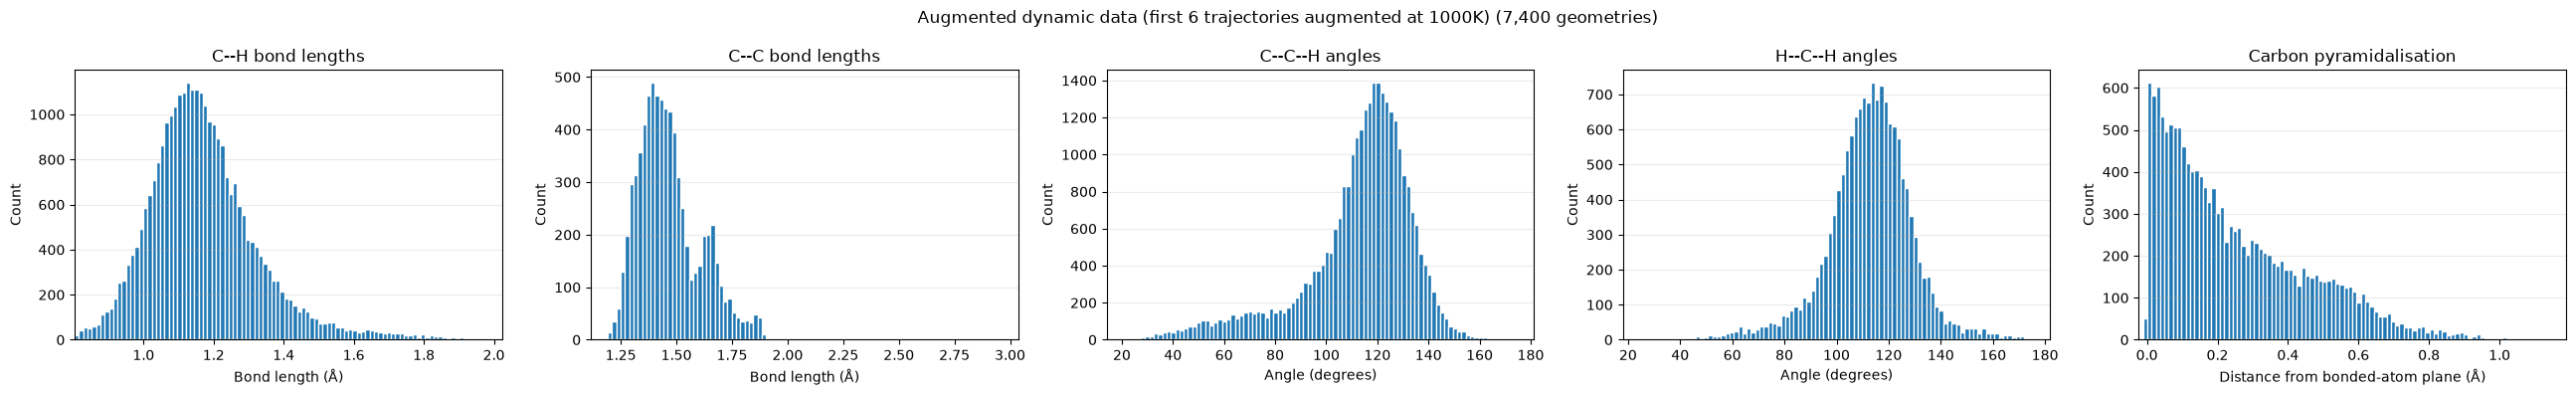

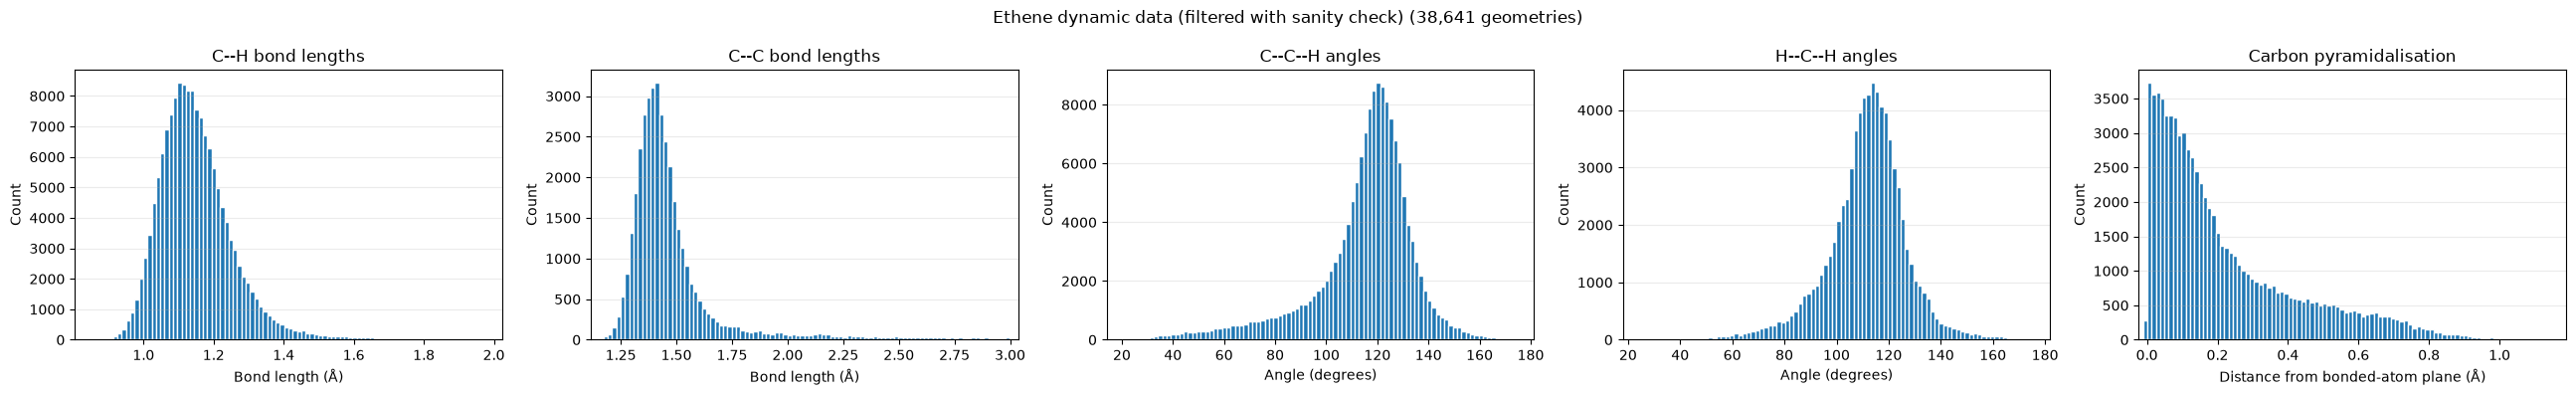

In [14]:
# Compare geometry distributions in an augmented XYZ file against its input XYZ file.
# This cell is standalone; set the two paths below for the files you want to compare.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

DATA_DIR = Path("../data") if Path("../data").is_dir() else Path("data")
ANALYSIS_XYZ = DATA_DIR / "A01_ethene/dynamic/A01_ethene_dynamic_CASSCF_sanity_defaults_filtered_first_740_wfl_normal_mode_sampling_1000k.xyz"
REFERENCE_XYZ = DATA_DIR / "A01_ethene/dynamic_gitignore/A01_ethene_dynamic_CASSCF_sanity_defaults_filtered.xyz"

for label, xyz_path in (("ANALYSIS_XYZ", ANALYSIS_XYZ), ("REFERENCE_XYZ", REFERENCE_XYZ)):
    if not xyz_path.is_file():
        raise FileNotFoundError(f"{label} file not found: {xyz_path.resolve()}")

# Atom order is C, C, H, H, H, H in both extended-XYZ files.
CH_PAIRS = ((0, 2), (0, 5), (1, 3), (1, 4))
CCH_TRIPLES = ((1, 0, 2), (1, 0, 5), (0, 1, 3), (0, 1, 4))
HCH_TRIPLES = ((2, 0, 5), (3, 1, 4))
PYRAMIDALISATION_SITES = ((0, (1, 2, 5)), (1, (0, 3, 4)))


def angle_degrees(positions, atom_i, central_atom, atom_j):
    first = positions[atom_i] - positions[central_atom]
    second = positions[atom_j] - positions[central_atom]
    cosine = np.dot(first, second) / (np.linalg.norm(first) * np.linalg.norm(second))
    return float(np.degrees(np.arccos(np.clip(cosine, -1.0, 1.0))))


def pyramidalisation(positions, carbon, plane_atoms):
    plane_origin, plane_atom1, plane_atom2 = positions[list(plane_atoms)]
    normal = np.cross(plane_atom1 - plane_origin, plane_atom2 - plane_origin)
    return float(abs(np.dot(positions[carbon] - plane_origin, normal)) / np.linalg.norm(normal))


def geometry_values(xyz_path):
    values = {
        "C--H": [], "C--C": [], "C--C--H": [], "H--C--H": [],
        "Pyramidalisation": [],
    }
    geometry_count = 0
    with xyz_path.open() as source:
        while atom_count_line := source.readline():
            atom_count = int(atom_count_line)
            source.readline()  # Extended-XYZ comment line.
            rows = [source.readline().split() for _ in range(atom_count)]
            if atom_count != 6 or [row[0] for row in rows] != ["C", "C", "H", "H", "H", "H"]:
                raise ValueError(f"Unexpected atom ordering in geometry {geometry_count} of {xyz_path}")
            positions = np.asarray([[float(value) for value in row[1:4]] for row in rows])
            values["C--C"].append(np.linalg.norm(positions[0] - positions[1]))
            values["C--H"].extend(np.linalg.norm(positions[i] - positions[j]) for i, j in CH_PAIRS)
            values["C--C--H"].extend(angle_degrees(positions, *atoms) for atoms in CCH_TRIPLES)
            values["H--C--H"].extend(angle_degrees(positions, *atoms) for atoms in HCH_TRIPLES)
            values["Pyramidalisation"].extend(
                pyramidalisation(positions, carbon, plane_atoms)
                for carbon, plane_atoms in PYRAMIDALISATION_SITES
            )
            geometry_count += 1
    if not geometry_count:
        raise ValueError(f"No geometries found in {xyz_path}")
    return geometry_count, values


PLOT_DEFINITIONS = (
    ("C--H", "C--H bond lengths", "Bond length (Å)"),
    ("C--C", "C--C bond lengths", "Bond length (Å)"),
    ("C--C--H", "C--C--H angles", "Angle (degrees)"),
    ("H--C--H", "H--C--H angles", "Angle (degrees)"),
    ("Pyramidalisation", "Carbon pyramidalisation", "Distance from bonded-atom plane (Å)"),
)


def shared_x_limits(*value_sets):
    limits = {}
    for key, _, _ in PLOT_DEFINITIONS:
        lower = min(np.min(values[key]) for values in value_sets)
        upper = max(np.max(values[key]) for values in value_sets)
        padding = 0.02 * (upper - lower) if upper > lower else max(0.01, 0.02 * abs(lower))
        limits[key] = (lower - padding, upper + padding)
    return limits


def plot_geometry_histograms(geometry_count, values, title, x_limits):
    fig, axes = plt.subplots(1, 5, figsize=(26, 4))
    for axis, (key, subplot_title, xlabel) in zip(axes, PLOT_DEFINITIONS):
        bins = np.linspace(*x_limits[key], num=101)
        axis.hist(values[key], bins=bins, color="tab:blue", edgecolor="white")
        axis.set(title=subplot_title, xlabel=xlabel, ylabel="Count", xlim=x_limits[key])
        axis.grid(axis="y", alpha=0.25)
    fig.suptitle(f"{title} ({geometry_count:,} geometries)")
    fig.tight_layout()
    plt.show()


analysis_count, analysis_values = geometry_values(ANALYSIS_XYZ)
reference_count, reference_values = geometry_values(REFERENCE_XYZ)
# Use the reference distribution alone to define the plotted x-axis ranges.
shared_limits = shared_x_limits(reference_values)

plot_geometry_histograms(
    analysis_count, analysis_values, "Augmented dynamic data (first 6 trajectories augmented at 1000K)", shared_limits
)
plot_geometry_histograms(
    reference_count, reference_values, "Ethene dynamic data (filtered with sanity check)", shared_limits
)
